In [22]:
from model_driver import driver
from iotools import read_results
import pandas as pd
from dotenv import load_dotenv
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pathlib
load_dotenv()

project_folder = Path(os.getenv('PROJECT_FOLDER'))
input_folder = os.path.join(project_folder, 'model_inputs')

%matplotlib widget

In [43]:
# # runs model
# outputfile = driver(create_ncf=True, folder=input_folder, param_module="parameters_ad")

# # reads results from .nc-file
# results = read_results(outputfile)

In [2]:
#outputfile = r'/Users/jpnousu/Library/CloudStorage/OneDrive-Luonnonvarakeskus/NordForsk_Proposal_Adaptive_drainage - General/SpaFHy-PEAT/model_inputs/results202603031331.nc'
#outputfile = r'/Users/jpnousu/Library/CloudStorage/OneDrive-Luonnonvarakeskus/NordForsk_Proposal_Adaptive_drainage - General/SpaFHy-PEAT/model_inputs/results202603041116.nc'
outputfile = input_folder + '/results202603051017.nc'
results = read_results(outputfile)

/Users/opa/ADAPTDAM/SpaFHy_Peat_AD/iotools.py:499: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  result.coords['i'] = -np.arange(0,result.dims['i'])
/Users/opa/ADAPTDAM/SpaFHy_Peat_AD/iotools.py:500: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  result.coords['j'] = np.arange(0,result.dims['j'])


In [10]:
results

<xarray.Dataset> Size: 38MB
Dimensions:                   (i: 429, j: 2, date: 10958)
Coordinates:
  * i                         (i) int64 3kB 0 -1 -2 -3 ... -425 -426 -427 -428
  * j                         (j) int64 16B 0 1
  * date                      (date) datetime64[ns] 88kB 1996-01-01 ... 2025-...
Data variables:
    parameters_lai_conif      (i, j) float32 3kB ...
    parameters_lai_decid_max  (i, j) float32 3kB ...
    parameters_cf             (i, j) float32 3kB ...
    parameters_soilclass      (i, j) float32 3kB ...
    parameters_ditch_depth    (i, j) float32 3kB ...
    parameters_ditch_spacing  (i, j) float32 3kB ...
    parameters_lat            (i, j) float32 3kB ...
    parameters_lon            (i, j) float32 3kB ...
    soil_ground_water_level   (date, i, j) float32 38MB ...
Attributes:
    description:  SpaFHy results : testcase
    history:      created 2026-03-05 10:17:18
    source:       modified SpaFHy v.1.0

In [3]:
# Select june-august data
summer = results['soil_ground_water_level'].sel(
    date=results['soil_ground_water_level'].date.dt.month.isin([6, 7, 8])
)

# Group by year and calculate summer mean for each year
summer_mean_by_year = summer.groupby('date.year').mean(dim='date')

# For real and adapt scenarios
real_mean_by_year = summer_mean_by_year.sel(j=0)
adapt_mean_by_year = summer_mean_by_year.sel(j=1)

# Overall mean across all years
real_overall_mean = real_mean_by_year.mean(dim='year').values
adapt_overall_mean = adapt_mean_by_year.mean(dim='year').values

# 10th and 90th percentile across all years
real_q10 = real_mean_by_year.quantile(0.1, dim='year').values
real_q90 = real_mean_by_year.quantile(0.9, dim='year').values

adapt_q10 = adapt_mean_by_year.quantile(0.1, dim='year').values
adapt_q90 = adapt_mean_by_year.quantile(0.9, dim='year').values

In [4]:

from collections import Counter

def get_soil_profile_info(soil_ids, peat_dict):
    peat_layers = []
    dominant_mineral = []

    for sid in soil_ids:
        key = f"soil_{int(sid)}"

        soil = peat_dict[key]
        soil_types = soil["soil_types"]

        # Count peat layers
        peat_layers.append(sum(t.startswith("Peat") for t in soil_types))

        # Filter mineral types
        mineral_types = [t for t in soil_types if t in ["Fine", "Coarse", "Medium"]]

        # Most common mineral type
        dom_mineral = 'Peat_only'
        if mineral_types:
            dom_mineral = Counter(mineral_types).most_common(1)[0][0]

        dominant_mineral.append(dom_mineral)

    return np.array(peat_layers), np.array(dominant_mineral)

from parameters_ad import peat_soilprofiles

peatp = peat_soilprofiles()

soil_ids = results['parameters_soilclass'][:,0].values
peat_layers, dominant_mineral = get_soil_profile_info(soil_ids, peatp)

dominant_mineral_numeric = np.zeros_like(dominant_mineral, dtype=float)
for i, val in enumerate(dominant_mineral):
    if val == 'Peat_only':
        dominant_mineral_numeric[i] = 0
    elif val == 'Fine':
        dominant_mineral_numeric[i] = 1
    elif val == 'Medium':
        dominant_mineral_numeric[i] = 2
    elif val == 'Coarse':
        dominant_mineral_numeric[i] = 3


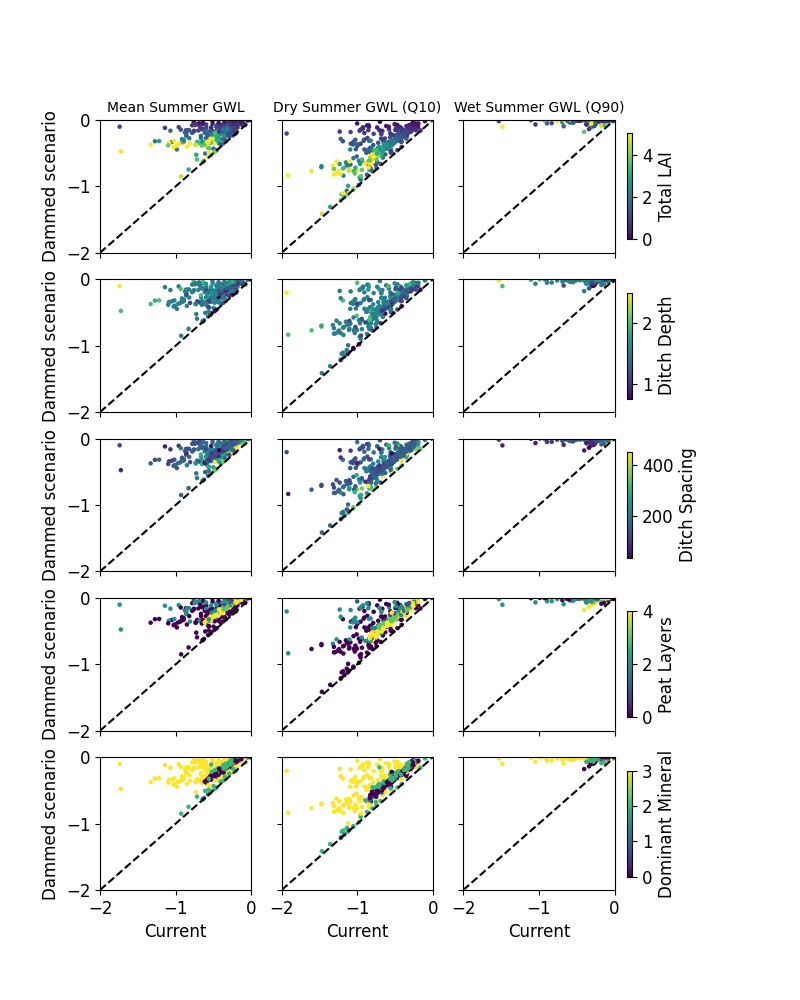

In [5]:

# Calculate total LAI
total_lai = results['parameters_lai_conif'][:,0] + results['parameters_lai_decid_max'][:,0]
soil_id = results['parameters_soilclass'][:,0]
ditch_depth = results['parameters_ditch_depth'][:,0]
ditch_spacing = results['parameters_ditch_spacing'][:,0]

color_vars = [total_lai, ditch_depth, ditch_spacing, peat_layers, dominant_mineral_numeric]
color_labels = ['Total LAI', 'Ditch Depth', 'Ditch Spacing', 'Peat Layers', 'Dominant Mineral']

fig, axes = plt.subplots(len(color_vars), 3, figsize=(8, 10), sharex=True, sharey=True)

for row, (color_var, color_label) in enumerate(zip(color_vars, color_labels)):
    # Fix color scale only for Total LAI row
    scatter_kwargs = {}
    if color_label == 'Total LAI':
        scatter_kwargs = {"vmin": 0, "vmax": 5}

    # Plot mean
    scatter0 = axes[row, 0].scatter(real_overall_mean, adapt_overall_mean, c=color_var, s=5, **scatter_kwargs)
    axes[row, 0].axline((0, 0), slope=1, linestyle='--', color='black')
    axes[row, 0].set_ylabel("Dammed scenario")
    if row == 0:
        axes[row, 0].set_title("Mean Summer GWL", fontsize=10)
    if row == len(color_vars) - 1:
        axes[row, 0].set_xlabel("Current")
    axes[row, 0].set_ylim([-2., 0.])
    axes[row, 0].set_xlim([-2., 0.])

    # Plot Q10
    scatter1 = axes[row, 1].scatter(real_q10, adapt_q10, c=color_var, s=5, **scatter_kwargs)
    axes[row, 1].axline((0, 0), slope=1, linestyle='--', color='black')
    if row == 0:
        axes[row, 1].set_title("Dry Summer GWL (Q10)", fontsize=10)
    if row == len(color_vars) - 1:
        axes[row, 1].set_xlabel("Current")
    axes[row, 1].set_ylim([-2., 0.])
    axes[row, 1].set_xlim([-2., 0.])

    # Plot Q90
    scatter2 = axes[row, 2].scatter(real_q90, adapt_q90, c=color_var, s=5, **scatter_kwargs)
    axes[row, 2].axline((0, 0), slope=1, linestyle='--', color='black')
    if row == 0:
        axes[row, 2].set_title("Wet Summer GWL (Q90)", fontsize=10)
    if row == len(color_vars) - 1:
        axes[row, 2].set_xlabel("Current")
    axes[row, 2].set_ylim([-2., 0.])
    axes[row, 2].set_xlim([-2., 0.])

    # Add colorbar for each row (will use the same mappable as the right-most scatter)
    cbar = plt.colorbar(scatter2, ax=axes[row, :], label=color_label, shrink=0.8, pad=0.02)

#plt.savefig(project_folder / 'model_inputs' / 'figures' / 'scatters_colors.png', dpi=150, bbox_inches = 'tight')


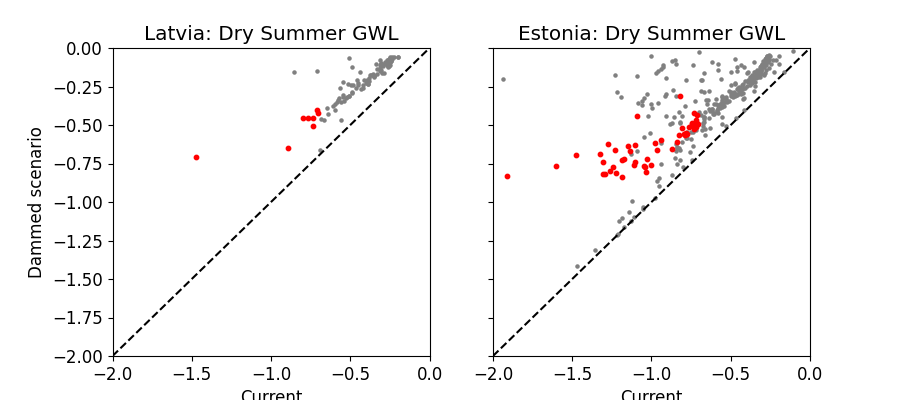

In [6]:
# Create categorical color variable based on latitude
lat = results['parameters_lat'][:,0]
lon = results['parameters_lon'][:,0]
color_var = np.where(lat > 57, 1, 0)  # 1 for lat > 57, 0 for lat <= 57

# Create separate indices for each category
idx_latvia = color_var == 0
idx_estonia = color_var == 1

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

# Selection criteria
ix_latvia = idx_latvia & (real_q10 < -0.7) & (real_q10 - adapt_q10 < -0.2) & (total_lai > 2)
ix_estonia = idx_estonia & (real_q10 < -0.7) & (real_q10 - adapt_q10 < -0.2) & (total_lai > 2)

for ax, idx, ix, country in zip(axes, [idx_latvia, idx_estonia], [ix_latvia, ix_estonia], ['Latvia', 'Estonia']):
    # Plot mean
    scatter0 = ax.scatter(real_q10[idx], adapt_q10[idx], c='grey', s=5)
    scatter0 = ax.scatter(real_q10[ix], adapt_q10[ix], c='red', s=10)
    ax.axline((0, 0), slope=1, linestyle='--', color='black')
    if country == 'Latvia':
        ax.set_ylabel("Dammed scenario")
    ax.set_title(f"{country}: Dry Summer GWL")
    ax.set_xlabel("Current")
    ax.set_ylim([-2., 0.])
    ax.set_xlim([-2., 0.])

#plt.savefig(project_folder / 'model_inputs' / 'figures' / 'scatter_selected.png', dpi=150, bbox_inches = 'tight')

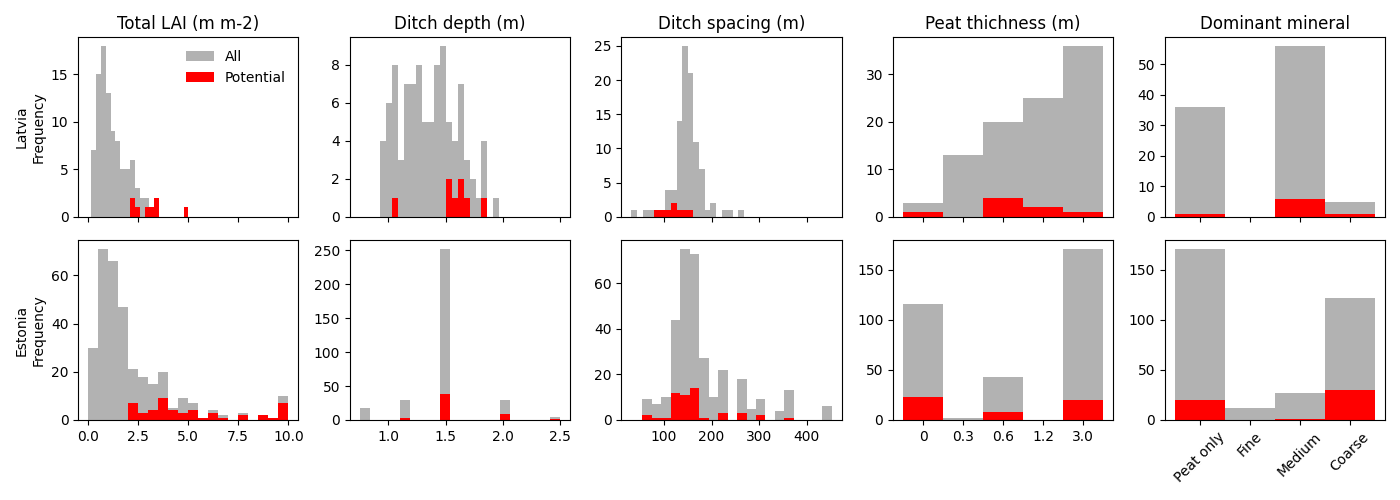

In [ ]:
# Create figure with histograms
fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharex='col')

variables = [total_lai, ditch_depth, ditch_spacing, peat_layers, dominant_mineral_numeric]
var_labels = ['Total LAI (m m-2)', 'Ditch depth (m)', 'Ditch spacing (m)', 'Peat thichness (m)', 'Dominant mineral']
# Latvia - Row 0

for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_latvia].min()
        var_max = var[idx_latvia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[0, col].hist(var[idx_latvia], bins=bins, label='All', alpha= 0.6, color='grey')
    axes[0, col].hist(var[ix_latvia], bins=bins, label='Potential', color='red')
    if label == 'Dominant mineral':
        axes[0, col].set_xticks([0, 1, 2, 3])
        axes[0, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[0, col].set_xticks([0, 1, 2, 3, 4])
        axes[0, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[0, col].set_ylabel("Latvia\nFrequency")
        axes[0, col].legend(frameon=False)
    axes[0, col].set_title(f"{label}")

# Estonia - Row 1
for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_estonia].min()
        var_max = var[idx_estonia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[1, col].hist(var[idx_estonia], bins=bins, label='All', alpha= 0.6, color='grey')
    axes[1, col].hist(var[ix_estonia], bins=bins, label='Potential', color='red')
    if label == 'Dominant mineral':
        axes[1, col].set_xticks([0, 1, 2, 3])
        axes[1, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[1, col].set_xticks([0, 1, 2, 3, 4])
        axes[1, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[1, col].set_ylabel("Estonia\nFrequency")

plt.tight_layout()

#plt.savefig(project_folder / 'model_inputs' / 'figures' / 'histograms_potential.png', dpi=150, bbox_inches = 'tight')

#plt.show()

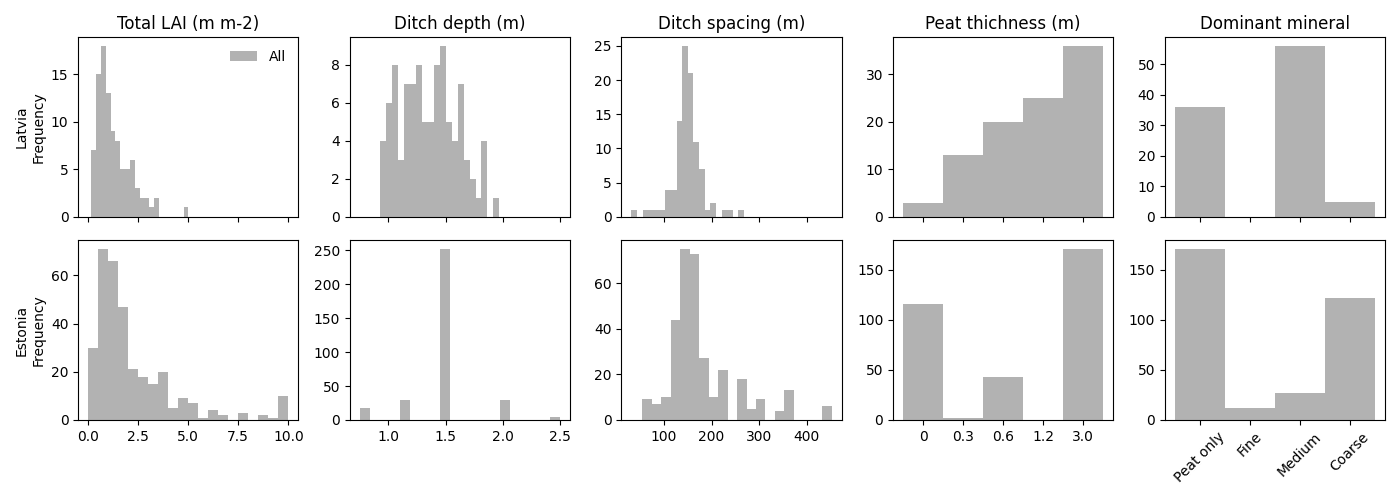

In [ ]:
# Create figure with histograms
fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharex='col')

variables = [total_lai, ditch_depth, ditch_spacing, peat_layers, dominant_mineral_numeric]
var_labels = ['Total LAI (m m-2)', 'Ditch depth (m)', 'Ditch spacing (m)', 'Peat thichness (m)', 'Dominant mineral']
# Latvia - Row 0

for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_latvia].min()
        var_max = var[idx_latvia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[0, col].hist(var[idx_latvia], bins=bins, label='All', alpha= 0.6, color='grey')
    if label == 'Dominant mineral':
        axes[0, col].set_xticks([0, 1, 2, 3])
        axes[0, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[0, col].set_xticks([0, 1, 2, 3, 4])
        axes[0, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[0, col].set_ylabel("Latvia\nFrequency")
        axes[0, col].legend(frameon=False)
    axes[0, col].set_title(f"{label}")

# Estonia - Row 1
for col, (var, label) in enumerate(zip(variables, var_labels)):
    # Calculate bins from combined min/max of both subsets
    try:
        var_min = var[idx_estonia].min()
        var_max = var[idx_estonia].max()
        bins = np.linspace(var_min.values, var_max.values, 21)
    except:
        if label == 'Dominant mineral':
            bins = np.arange(-0.5, 4.5, 1)  # For categorical variable with 4 categories
        else:
            bins = np.arange(-0.5, 5.5, 1)
    axes[1, col].hist(var[idx_estonia], bins=bins, label='All', alpha= 0.6, color='grey')
    if label == 'Dominant mineral':
        axes[1, col].set_xticks([0, 1, 2, 3])
        axes[1, col].set_xticklabels(['Peat only', 'Fine', 'Medium', 'Coarse'], rotation=45)
    elif label == 'Peat thichness (m)':
        axes[1, col].set_xticks([0, 1, 2, 3, 4])
        axes[1, col].set_xticklabels(['0', '0.3', '0.6', '1.2', '3.0'])
    if col == 0:
        axes[1, col].set_ylabel("Estonia\nFrequency")

plt.tight_layout()

#plt.savefig(project_folder / 'model_inputs' / 'figures' / 'histograms.png', dpi=150, bbox_inches = 'tight')

#plt.show()

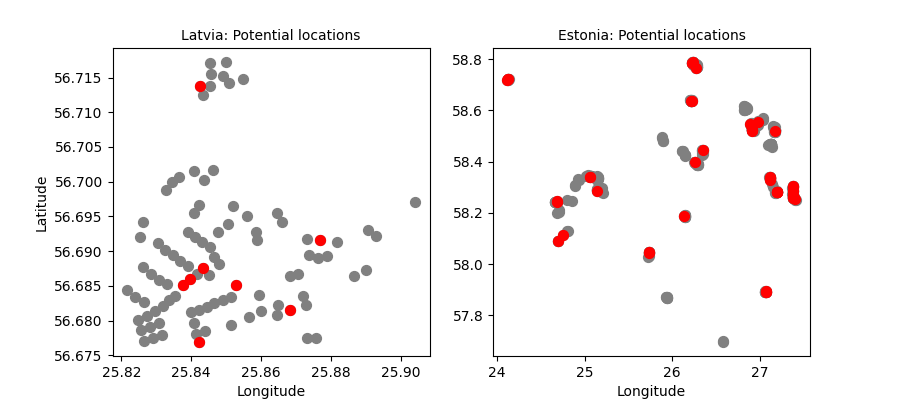

97 332 429


In [ ]:
# Get lat/lon coordinates
lat = results['parameters_lat'][:,0]
lon = results['parameters_lon'][:,0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, idx, ix, country in zip(axes, [idx_latvia, idx_estonia], [ix_latvia, ix_estonia], ['Latvia', 'Estonia']):
    ax.scatter(lon[idx], lat[idx], c='grey', s=50)
    ax.scatter(lon[ix], lat[ix], c='red', s=50)
    ax.set_xlabel("Longitude")
    if country == 'Latvia':
        ax.set_ylabel("Latitude")
    ax.set_title(f"{country}: Potential locations", fontsize=10)

#plt.savefig(project_folder / 'model_inputs' / 'figures' / 'scatter_potential_locations.png', dpi=150, bbox_inches = 'tight')
#plt.show()

print(len(lon[idx_latvia]),len(lon[idx_estonia]), len(lon))

In [51]:

summer_mean = summer.mean(dim='date')
real_mean = summer_mean.sel(j=0)
adapt_mean = summer_mean.sel(j=1)



summer_site_mean = summer.mean(dim='i')
summer_site_low = summer.quantile(0.25, dim='i')
summer_site_high = summer.quantile(0.75, dim='i')

summer_climatology = summer_site_mean.groupby('date.dayofyear').mean(dim='date')
summer_climatology_low = summer_site_low.groupby('date.dayofyear').mean(dim='date')
summer_climatology_high = summer_site_high.groupby('date.dayofyear').mean(dim='date')

real_clim = summer_climatology.sel(j=0)
real_clim_low = summer_climatology_low.sel(j=0)
real_clim_high = summer_climatology_high.sel(j=0)

adapt_clim = summer_climatology.sel(j=1)
adapt_clim_low = summer_climatology_low.sel(j=1)
adapt_clim_high = summer_climatology_high.sel(j=1)

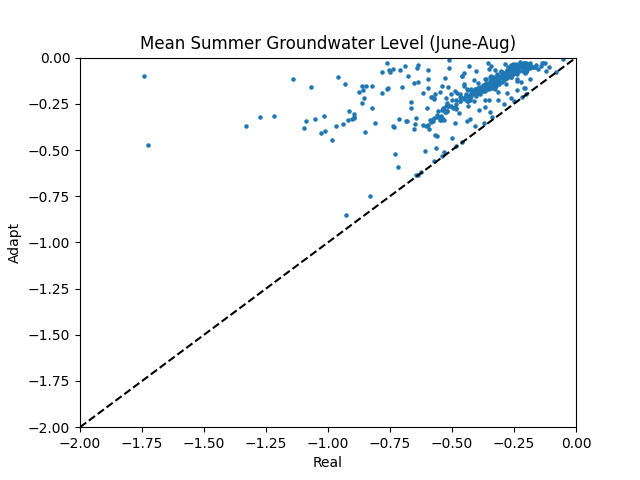

In [52]:
plt.figure()
plt.scatter(real_mean, adapt_mean, s=5)
plt.axline((0, 0), slope=1, linestyle='--', color='black')  # 1:1 line
plt.xlabel("Real")
plt.ylabel("Adapt")
plt.title("Mean Summer Groundwater Level (June-Aug)")
plt.ylim([-2.,0.])
plt.xlim([-2.,0.])
plt.show()

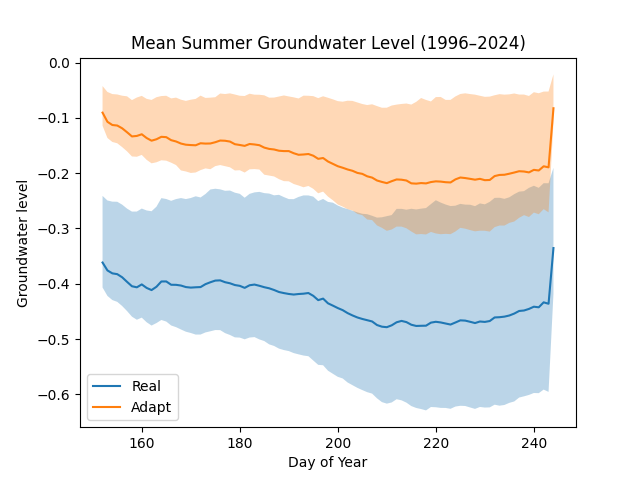

In [53]:
import matplotlib.pyplot as plt

# x-axis (day of year)
x = real_clim['dayofyear'].values

plt.figure()

# --- Real ---
plt.plot(x, real_clim.values, label="Real")
plt.fill_between(
    x,
    real_clim_low.values,
    real_clim_high.values,
    alpha=0.3
)

# --- Adapt ---
plt.plot(x, adapt_clim.values, label="Adapt")
plt.fill_between(
    x,
    adapt_clim_low.values,
    adapt_clim_high.values,
    alpha=0.3
)

plt.legend()
plt.title("Mean Summer Groundwater Level (1996–2024)")
plt.ylabel("Groundwater level")
plt.xlabel("Day of Year")
plt.show()

# Get dominant trees

In [66]:
LAI_folder = pathlib.Path(os.getenv('PROJECT_FOLDER') + '/model_inputs/LAI_cf/')
LAI_est = pd.read_csv(LAI_folder/'EST_LAI_capped_to_10_cf.csv', index_col='Site_id')
LAI_lat = pd.read_csv(LAI_folder/'LAT_LAI_cf.csv', index_col='Site_id')

In [67]:
est_plots = [(lat.values.flatten()[0], lon.values.flatten()[0]) for lat, lon in zip(lat[ix_estonia], lon[ix_estonia])]
lat_plots = [(lat.values.flatten()[0], lon.values.flatten()[0]) for lat, lon in zip(lat[ix_latvia], lon[ix_latvia])]

In [93]:
# Get dominant tree name for each row
#Est
lai_cols_est = [
    "LAI_spruce",
    "LAI_pine",
    "LAI_birch",
    "LAI_aspen",
    "LAI_grey_alder",
    "LAI_black_alder",
]

LAI_est = LAI_est.assign(LAI_max_label=LAI_est[lai_cols_est].idxmax(axis=1))
LAI_est['LAI_max_label'] = LAI_est['LAI_max_label'].apply(lambda x: " ".join(x.split('_')[1:]))

#lat
lai_cols_lat = [
    "LAI_spruce",
    "LAI_pine",
    "LAI_birch",
]
LAI_lat = LAI_lat.assign(LAI_max_label=LAI_lat[lai_cols_lat].idxmax(axis=1))
LAI_lat['LAI_max_label'] = LAI_lat['LAI_max_label'].apply(lambda x: x.split('_')[1])

In [94]:
# Choos selected plots from LAI_est
df_float32 = LAI_est.astype({'lat': 'float32', 'lon': 'float32'})

coord_set = set(est_plots)
mask = [(lat, lon) in coord_set for lat, lon in zip(df_float32['lat'].to_numpy(), df_float32['lon'].to_numpy())]
est_selected = df_float32.loc[mask, :]

#This needs to print true (ensures that we have selected all of the plots we want)
est_selected.shape[0] == np.sum(ix_estonia.values)

np.True_

In [95]:
# Choos selected plots from LAI_est
df_float32 = LAI_lat.astype({'lat': 'float32', 'lon': 'float32'})

coord_set = set(lat_plots)
mask = [(lat, lon) in coord_set for lat, lon in zip(df_float32['lat'].to_numpy(), df_float32['lon'].to_numpy())]
lat_selected = df_float32.loc[mask, :]

#This needs to print true (ensures that we have selected all of the plots we want)
lat_selected.shape[0] == np.sum(ix_latvia.values)

np.True_

## Plot dominant tree species

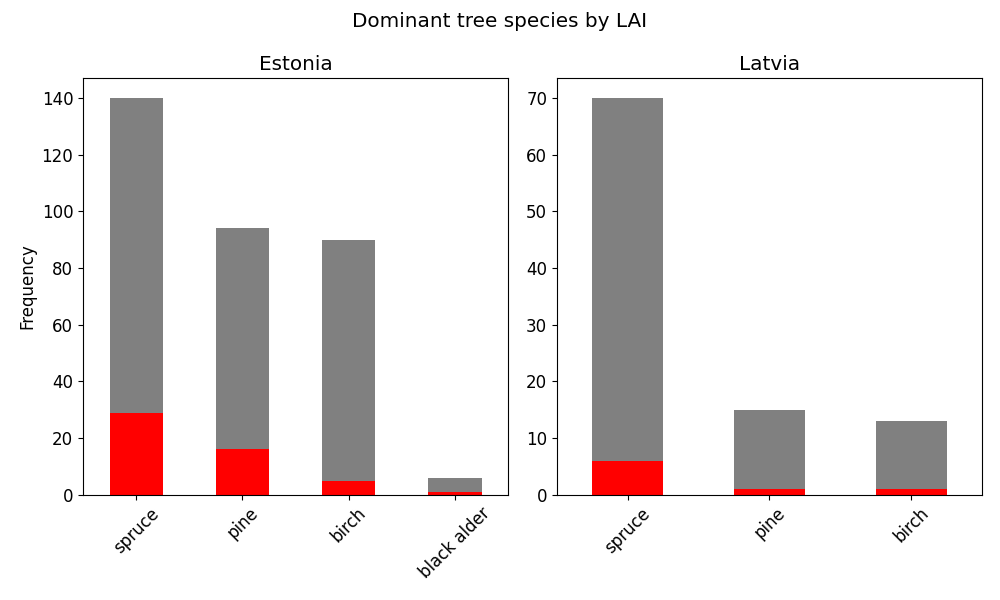

In [103]:
fig, axs = plt.subplots(nrows=1, ncols=2)
axs = axs.flatten()

LAI_est['LAI_max_label'].value_counts().plot(kind='bar', ax=axs[0], color='gray')
est_selected['LAI_max_label'].value_counts().plot(kind="bar", ax=axs[0], color='red')
LAI_lat['LAI_max_label'].value_counts().plot(kind='bar', ax=axs[1], color='gray')
lat_selected['LAI_max_label'].value_counts().plot(kind="bar", ax=axs[1], color='red')

axs[0].set_xlabel('')
axs[0].set_ylabel("Frequency")
axs[0].set_xticklabels(labels = axs[0].get_xticklabels(), rotation=45)
axs[0].set_title('Estonia')

axs[1].set_xlabel('')
axs[1].set_xticklabels(labels = axs[1].get_xticklabels(), rotation=45)
axs[1].set_title('Latvia')
fig.suptitle("Dominant tree species by LAI")
plt.tight_layout()

